# GBM vs Random Forest using XGBoost in Python

This notebook demonstrates the key differences between **Gradient Boosting (GBM)** and **Random Forest** implementations using XGBoost.

## Key Differences:
- **Boosting (GBM)**: `num_parallel_tree=1`, `n_estimators=many` - Trees added sequentially
- **Random Forest**: `num_parallel_tree=many`, `n_estimators=1` - Trees built independently in parallel

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    classification_report,
    mean_squared_error,
    r2_score,
    brier_score_loss,
    log_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("[OK] Libraries imported successfully!")
print(f"XGBoost version: {XGBClassifier().get_xgb_params()['base_score']}")

[OK] Libraries imported successfully!
XGBoost version: None


## 2. Load Data from Online Source

In [2]:
# Load data from online source
file_path = 'https://raw.githubusercontent.com/axspinnacle/cfs25/main/data/'
file_name = 'data5.ftr'

print("Loading data from online source...")
try:
    df_ini = pd.read_feather(file_path + file_name)
    print(f"✓ Data loaded successfully!")
    print(f"  Shape: {df_ini.shape}")
    print(f"  Columns: {len(df_ini.columns)}")
except Exception as e:
    print(f"✗ Error loading data: {e}")
    print("Creating sample data for demonstration...")
    np.random.seed(42)
    n_samples = 5000
    df_ini = pd.DataFrame({
        'feature1': np.random.normal(0, 1, n_samples),
        'feature2': np.random.normal(2, 0.5, n_samples),
        'feature3': np.random.randint(0, 5, n_samples),
        'feature4': np.random.exponential(1, n_samples),
        'feature5': np.random.uniform(0, 10, n_samples),
        'cc_col': np.random.randint(0, 2, n_samples)  # Binary target
    })
    print(f"  Sample data created with shape: {df_ini.shape}")

# Create working copy
df = df_ini.copy()
print("\nFirst few rows:")
df.head()

Loading data from online source...
✓ Data loaded successfully!
  Shape: (100443, 66)
  Columns: 66

First few rows:


,pol_eff_year,ep_bi,ep_col,ee_bi,ee_col,incloss_bi,incloss_col,cc_bi,cc_col,zip,...,diploma_ntile,pop_density_ntile,unemployment_ntile,Modeled_Annual_Mileage_null_flag,Estimated_Current_Mileage_null_flag,Annual_Mileage_Estimate_null_flag,Number_of_Titling_Transactions_null_flag,LOO_years_null_flag,curr_owner_odo_cnt_null_flag,all_owner_odo_cnt_null_flag
0,2015,161.00,419.00,0.999708,0.999708,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,1,0,0,0,0
1,2017,269.00,416.00,1.000000,1.000000,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,0,0,0,0,0
2,2014,105.57,315.06,1.000000,1.000000,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,0,0,0,0,0
3,2016,258.00,425.00,1.000292,1.000292,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,0,0,0,0,0
4,2014,23.83,55.72,0.169863,0.169863,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,1,1,0,0,0,0


## 3. Data Preprocessing

In [3]:
# Remove unnecessary columns (if they exist)
cols_to_remove = ['ep_bi', 'ep_col', 'ee_bi', 'ee_col', 'incloss_bi', 'incloss_col', 'cc_bi', 'zip', 'pol_id', 'vin_id', 'Date']
existing_cols_to_remove = [col for col in cols_to_remove if col in df.columns]

if existing_cols_to_remove:
    df = df.drop(columns=existing_cols_to_remove)
    print(f"Removed columns: {existing_cols_to_remove}")

# Define target column
target_column = "cc_col"
print(f"\nUsing '{target_column}' as target variable")

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nOriginal target distribution:")
print(y.value_counts().sort_index())

# Convert cc_col to binary: all values >= 1 become 1
print(f"\nConverting target to binary (values >= 1 -> 1)...")
y = (y >= 1).astype(int)

print(f"\nAfter binary conversion:")
print(y.value_counts().sort_index())
print(f"\nTarget distribution (%):")
print(y.value_counts(normalize=True) * 100)
print(f"✓ Target converted to binary classification")

Removed columns: ['ep_bi', 'ep_col', 'ee_bi', 'ee_col', 'incloss_bi', 'incloss_col', 'cc_bi', 'zip', 'pol_id', 'vin_id', 'Date']

Using 'cc_col' as target variable

Features shape: (100443, 54)
Target shape: (100443,)

Original target distribution:
cc_col
0    98418
1     1977
2       40
3        5
4        1
6        1
8        1
Name: count, dtype: int64

Converting target to binary (values >= 1 -> 1)...

After binary conversion:
cc_col
0    98418
1     2025
Name: count, dtype: int64

Target distribution (%):
cc_col
0    97.983931
1     2.016069
Name: proportion, dtype: float64
✓ Target converted to binary classification


In [4]:
# Handle categorical variables
categorical_columns = X.select_dtypes(include=['object', 'category']).columns
if len(categorical_columns) > 0:
    print(f"Encoding categorical columns: {list(categorical_columns)}")
    le = LabelEncoder()
    for col in categorical_columns:
        X[col] = le.fit_transform(X[col].astype(str))
    print("✓ Categorical variables encoded")
else:
    print("✓ No categorical variables found")

# Handle missing values
if X.isnull().sum().sum() > 0:
    print(f"\nFilling {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median())
    print("✓ Missing values handled")
else:
    print("\n✓ No missing values found")

print("\n✓ Data preprocessing complete!")

✓ No categorical variables found

✓ No missing values found

✓ Data preprocessing complete!


## 4. Train-Test Split

Using consistent random_state=42 for fair comparison

In [5]:
# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set: 80354 samples
Test set: 20089 samples

Training target distribution:
cc_col
0    78734
1     1620
Name: count, dtype: int64

Test target distribution:
cc_col
0    19684
1      405
Name: count, dtype: int64


## 5. Model Configurations

### Gradient Boosting (GBM) Model
- **Sequential tree building**: Each tree corrects errors of previous trees
- `n_estimators=200` (many boosting rounds)
- `num_parallel_tree=1` (one tree per round)
- `learning_rate=0.05` (slower learning)

In [6]:
# Determine if binary or multiclass
n_classes = len(y.unique())
is_binary = n_classes == 2

print(f"Problem type: {'Binary' if is_binary else 'Multiclass'} Classification")
print(f"Number of classes: {n_classes}")

# GBM Model Configuration
print("\n" + "="*60)
print("GRADIENT BOOSTING MODEL (GBM)")
print("="*60)

boost_model = XGBClassifier(
    n_estimators=200,           # Many boosting rounds
    num_parallel_tree=1,        # One tree per round (sequential)
    max_depth=6,                # Tree depth
    learning_rate=0.05,         # Slower learning rate
    subsample=0.8,              # Row sampling
    colsample_bytree=0.8,       # Column sampling per tree
    random_state=42,
    eval_metric='logloss' if is_binary else 'mlogloss',
    tree_method='hist'
)

print(f"Configuration:")
print(f"  - n_estimators: 200 (sequential rounds)")
print(f"  - num_parallel_tree: 1")
print(f"  - learning_rate: 0.05")
print(f"  - max_depth: 6")
print(f"  - Total trees: 200 × 1 = 200 trees")
print(f"\nTraining GBM model...")

start_time = time.time()
boost_model.fit(X_train, y_train, verbose=False)
boost_train_time = time.time() - start_time

print(f"✓ Training completed in {boost_train_time:.2f} seconds")

Problem type: Binary Classification
Number of classes: 2

GRADIENT BOOSTING MODEL (GBM)
Configuration:
  - n_estimators: 200 (sequential rounds)
  - num_parallel_tree: 1
  - learning_rate: 0.05
  - max_depth: 6
  - Total trees: 200 × 1 = 200 trees

Training GBM model...
✓ Training completed in 0.69 seconds


### Random Forest Model
- **Parallel tree building**: All trees built independently
- `n_estimators=1` (single boosting round)
- `num_parallel_tree=200` (200 trees built in parallel)
- `learning_rate=1` (no shrinkage)

In [7]:
print("="*60)
print("RANDOM FOREST MODEL (using XGBoost)")
print("="*60)

rf_model = XGBClassifier(
    n_estimators=1,             # Single boosting iteration
    num_parallel_tree=200,      # 200 trees in parallel
    max_depth=6,                # Same tree depth
    learning_rate=1,            # No shrinkage
    subsample=0.8,              # Row sampling (bagging)
    colsample_bynode=0.8,       # Feature sampling per split (like RF)
    random_state=42,
    eval_metric='logloss' if is_binary else 'mlogloss',
    tree_method='hist'
)

print(f"Configuration:")
print(f"  - n_estimators: 1 (single round)")
print(f"  - num_parallel_tree: 200")
print(f"  - learning_rate: 1.0")
print(f"  - max_depth: 6")
print(f"  - Total trees: 1 × 200 = 200 trees")
print(f"\nTraining Random Forest model...")

start_time = time.time()
rf_model.fit(X_train, y_train, verbose=False)
rf_train_time = time.time() - start_time

print(f"[OK] Training completed in {rf_train_time:.2f} seconds")

RANDOM FOREST MODEL (using XGBoost)
Configuration:
  - n_estimators: 1 (single round)
  - num_parallel_tree: 200
  - learning_rate: 1.0
  - max_depth: 6
  - Total trees: 1 × 200 = 200 trees

Training Random Forest model...
[OK] Training completed in 0.69 seconds


### GBRF (Gradient Boosted Random Forest) - Hybrid Model
- **Hybrid approach**: Combines boosting and bagging
- `n_estimators=40` (moderate boosting rounds)
- `num_parallel_tree=5` (5 trees per round)
- `learning_rate=0.15` (between GBM and RF)

In [8]:
print("="*60)
print("GBRF MODEL (Gradient Boosted Random Forest - Hybrid)")
print("="*60)

gbrf_model = XGBClassifier(
    n_estimators=40,            # Moderate boosting rounds
    num_parallel_tree=5,        # 5 trees per round (hybrid)
    max_depth=6,                # Same tree depth
    learning_rate=0.15,         # Between GBM (0.05) and RF (1.0)
    subsample=0.8,              # Row sampling
    colsample_bynode=0.8,       # Feature sampling per split
    random_state=42,
    eval_metric='logloss' if is_binary else 'mlogloss',
    tree_method='hist'
)

print(f"Configuration:")
print(f"  - n_estimators: 40 (boosting rounds)")
print(f"  - num_parallel_tree: 5")
print(f"  - learning_rate: 0.15")
print(f"  - max_depth: 6")
print(f"  - Total trees: 40 x 5 = 200 trees")
print(f"  - Strategy: Gradient boosting with 5 parallel trees per round")
print(f"\nTraining GBRF model...")

start_time = time.time()
gbrf_model.fit(X_train, y_train, verbose=False)
gbrf_train_time = time.time() - start_time

print(f"[OK] Training completed in {gbrf_train_time:.2f} seconds")

GBRF MODEL (Gradient Boosted Random Forest - Hybrid)
Configuration:
  - n_estimators: 40 (boosting rounds)
  - num_parallel_tree: 5
  - learning_rate: 0.15
  - max_depth: 6
  - Total trees: 40 x 5 = 200 trees
  - Strategy: Gradient boosting with 5 parallel trees per round

Training GBRF model...
[OK] Training completed in 1.01 seconds


## 6. Model Predictions and Metrics

We'll evaluate all three models on:
- Train and Test sets
- Calculate AUC (for classification)
- Measure inference time

In [9]:
# GBM Predictions
print("Making predictions with GBM model...")
start_time = time.time()
boost_train_pred = boost_model.predict(X_train)
boost_test_pred = boost_model.predict(X_test)
boost_inference_time = time.time() - start_time

# Get probability predictions for AUC
boost_train_proba = boost_model.predict_proba(X_train)
boost_test_proba = boost_model.predict_proba(X_test)

print(f"✓ GBM predictions completed in {boost_inference_time:.4f} seconds")

# Random Forest Predictions
print("\nMaking predictions with Random Forest model...")
start_time = time.time()
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_inference_time = time.time() - start_time

# Get probability predictions for AUC
rf_train_proba = rf_model.predict_proba(X_train)
rf_test_proba = rf_model.predict_proba(X_test)

print(f"[OK] RF predictions completed in {rf_inference_time:.4f} seconds")

# GBRF Predictions
print("\nMaking predictions with GBRF model...")
start_time = time.time()
gbrf_train_pred = gbrf_model.predict(X_train)
gbrf_test_pred = gbrf_model.predict(X_test)
gbrf_inference_time = time.time() - start_time

# Get probability predictions for AUC
gbrf_train_proba = gbrf_model.predict_proba(X_train)
gbrf_test_proba = gbrf_model.predict_proba(X_test)

print(f"[OK] GBRF predictions completed in {gbrf_inference_time:.4f} seconds")

Making predictions with GBM model...
✓ GBM predictions completed in 0.0579 seconds

Making predictions with Random Forest model...
[OK] RF predictions completed in 0.0580 seconds

Making predictions with GBRF model...
[OK] GBRF predictions completed in 0.0567 seconds


In [10]:
# Calculate AUC metrics for all 3 models
if is_binary:
    # Binary classification - use column 1 for positive class
    boost_train_auc = roc_auc_score(y_train, boost_train_proba[:, 1])
    boost_test_auc = roc_auc_score(y_test, boost_test_proba[:, 1])
    rf_train_auc = roc_auc_score(y_train, rf_train_proba[:, 1])
    rf_test_auc = roc_auc_score(y_test, rf_test_proba[:, 1])
    gbrf_train_auc = roc_auc_score(y_train, gbrf_train_proba[:, 1])
    gbrf_test_auc = roc_auc_score(y_test, gbrf_test_proba[:, 1])
    metric_name = "AUC"
else:
    # Multiclass - use ovr (one-vs-rest)
    boost_train_auc = roc_auc_score(y_train, boost_train_proba, multi_class='ovr')
    boost_test_auc = roc_auc_score(y_test, boost_test_proba, multi_class='ovr')
    rf_train_auc = roc_auc_score(y_train, rf_train_proba, multi_class='ovr')
    rf_test_auc = roc_auc_score(y_test, rf_test_proba, multi_class='ovr')
    gbrf_train_auc = roc_auc_score(y_train, gbrf_train_proba, multi_class='ovr')
    gbrf_test_auc = roc_auc_score(y_test, gbrf_test_proba, multi_class='ovr')
    metric_name = "AUC (OVR)"

# Calculate accuracies for all 3 models
boost_train_acc = accuracy_score(y_train, boost_train_pred)
boost_test_acc = accuracy_score(y_test, boost_test_pred)
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
gbrf_train_acc = accuracy_score(y_train, gbrf_train_pred)
gbrf_test_acc = accuracy_score(y_test, gbrf_test_pred)

# Calculate Brier scores for all 3 models
boost_train_brier = brier_score_loss(y_train, boost_train_proba[:, 1]) if is_binary else 0
boost_test_brier = brier_score_loss(y_test, boost_test_proba[:, 1]) if is_binary else 0
rf_train_brier = brier_score_loss(y_train, rf_train_proba[:, 1]) if is_binary else 0
rf_test_brier = brier_score_loss(y_test, rf_test_proba[:, 1]) if is_binary else 0
gbrf_train_brier = brier_score_loss(y_train, gbrf_train_proba[:, 1]) if is_binary else 0
gbrf_test_brier = brier_score_loss(y_test, gbrf_test_proba[:, 1]) if is_binary else 0

# Calculate Log Loss for all 3 models
boost_train_logloss = log_loss(y_train, boost_train_proba)
boost_test_logloss = log_loss(y_test, boost_test_proba)
rf_train_logloss = log_loss(y_train, rf_train_proba)
rf_test_logloss = log_loss(y_test, rf_test_proba)
gbrf_train_logloss = log_loss(y_train, gbrf_train_proba)
gbrf_test_logloss = log_loss(y_test, gbrf_test_proba)

# Calculate generalization gaps
boost_gap = boost_train_auc - boost_test_auc
rf_gap = rf_train_auc - rf_test_auc
gbrf_gap = gbrf_train_auc - gbrf_test_auc

print("[OK] All metrics calculated successfully for 3 models!")

[OK] All metrics calculated successfully for 3 models!


## 7. Comprehensive Comparison

### Generalization Gap
The **generalization gap** (Train Metric - Test Metric) is a key indicator of model capacity:
- **Larger gap**: Higher capacity model, potential overfitting
- **Smaller gap**: Better generalization to unseen data

In [11]:
# Create comprehensive comparison dataframe for all 3 models
comparison_df = pd.DataFrame({
    'Metric': [
        f'Train {metric_name}',
        f'Test {metric_name}',
        'Generalization Gap',
        'Train Accuracy',
        'Test Accuracy',
        'Test Brier Score',
        'Test Log Loss',
        'Total Trees',
        'Max Depth',
        'Training Time (s)',
        'Inference Time (s)'
    ],
    'GBM': [
        f"{boost_train_auc:.4f}",
        f"{boost_test_auc:.4f}",
        f"{boost_gap:.4f}",
        f"{boost_train_acc:.4f}",
        f"{boost_test_acc:.4f}",
        f"{boost_test_brier:.4f}" if is_binary else "N/A",
        f"{boost_test_logloss:.4f}",
        "200",
        "6",
        f"{boost_train_time:.4f}",
        f"{boost_inference_time:.4f}"
    ],
    'RF': [
        f"{rf_train_auc:.4f}",
        f"{rf_test_auc:.4f}",
        f"{rf_gap:.4f}",
        f"{rf_train_acc:.4f}",
        f"{rf_test_acc:.4f}",
        f"{rf_test_brier:.4f}" if is_binary else "N/A",
        f"{rf_test_logloss:.4f}",
        "200",
        "6",
        f"{rf_train_time:.4f}",
        f"{rf_inference_time:.4f}"
    ],
    'GBRF': [
        f"{gbrf_train_auc:.4f}",
        f"{gbrf_test_auc:.4f}",
        f"{gbrf_gap:.4f}",
        f"{gbrf_train_acc:.4f}",
        f"{gbrf_test_acc:.4f}",
        f"{gbrf_test_brier:.4f}" if is_binary else "N/A",
        f"{gbrf_test_logloss:.4f}",
        "200",
        "6",
        f"{gbrf_train_time:.4f}",
        f"{gbrf_inference_time:.4f}"
    ]
})

print("="*90)
print("3-MODEL COMPARISON SUMMARY (GBM vs RF vs GBRF)")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)

3-MODEL COMPARISON SUMMARY (GBM vs RF vs GBRF)
            Metric    GBM     RF   GBRF
         Train AUC 0.9204 0.7204 0.8743
          Test AUC 0.6165 0.6132 0.6286
Generalization Gap 0.3039 0.1072 0.2457
    Train Accuracy 0.9799 0.9798 0.9798
     Test Accuracy 0.9798 0.9798 0.9798
  Test Brier Score 0.0197 0.0208 0.0197
     Test Log Loss 0.0971 0.1121 0.0964
       Total Trees    200    200    200
         Max Depth      6      6      6
 Training Time (s) 0.6887 0.6870 1.0062
Inference Time (s) 0.0579 0.0580 0.0567


In [12]:
# Interpretation
print("\nINTERPRETATION:")
print("\n1. GENERALIZATION GAP:")
print(f"   - GBM Gap: {boost_gap:.4f}")
print(f"   - RF Gap: {rf_gap:.4f}")
if boost_gap > rf_gap:
    print("   -> GBM shows larger gap, indicating higher model capacity but potentially more overfitting")
else:
    print("   -> RF shows larger gap, indicating higher model capacity but potentially more overfitting")

print("\n2. TEST PERFORMANCE:")
print(f"   - GBM Test {metric_name}: {boost_test_auc:.4f}")
print(f"   - RF Test {metric_name}: {rf_test_auc:.4f}")
if boost_test_auc > rf_test_auc:
    print(f"   -> GBM performs better on test set by {(boost_test_auc - rf_test_auc):.4f}")
else:
    print(f"   -> RF performs better on test set by {(rf_test_auc - boost_test_auc):.4f}")

print("\n3. COMPUTATIONAL EFFICIENCY:")
print(f"   - GBM Training: {boost_train_time:.4f}s | Inference: {boost_inference_time:.4f}s")
print(f"   - RF Training: {rf_train_time:.4f}s | Inference: {rf_inference_time:.4f}s")
if rf_train_time < boost_train_time:
    print(f"   -> RF trains {boost_train_time/rf_train_time:.2f}x faster (parallel tree building)")
else:
    print(f"   -> GBM trains {rf_train_time/boost_train_time:.2f}x faster")


INTERPRETATION:

1. GENERALIZATION GAP:
   - GBM Gap: 0.3039
   - RF Gap: 0.1072
   -> GBM shows larger gap, indicating higher model capacity but potentially more overfitting

2. TEST PERFORMANCE:
   - GBM Test AUC: 0.6165
   - RF Test AUC: 0.6132
   -> GBM performs better on test set by 0.0032

3. COMPUTATIONAL EFFICIENCY:
   - GBM Training: 0.6887s | Inference: 0.0579s
   - RF Training: 0.6870s | Inference: 0.0580s
   -> RF trains 1.00x faster (parallel tree building)


## 8. Visualizations

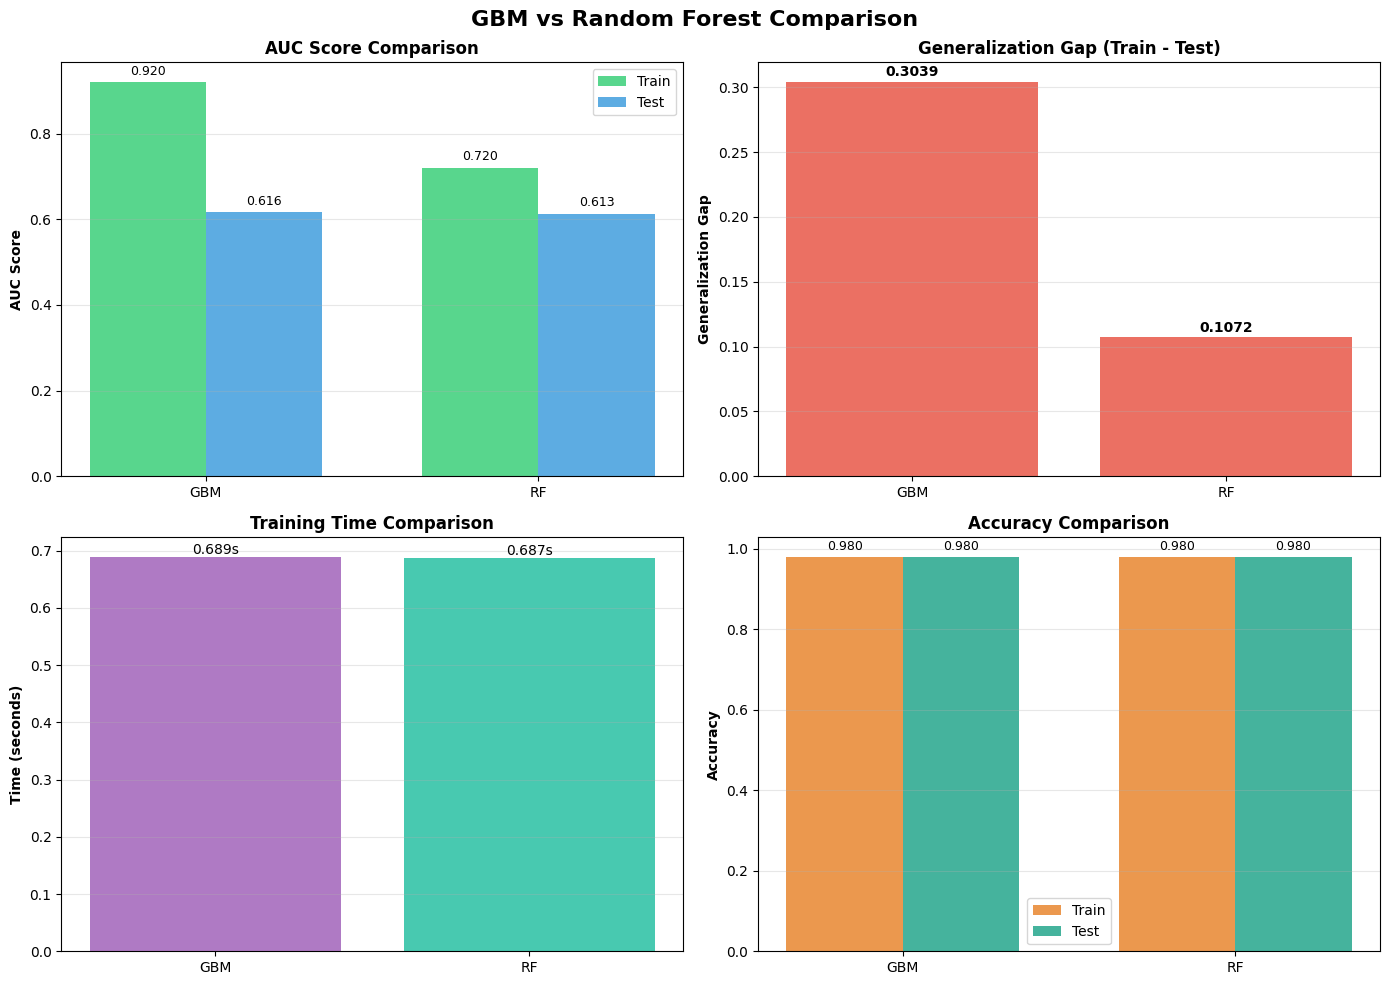

In [13]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GBM vs Random Forest Comparison', fontsize=16, fontweight='bold')

# 1. AUC Comparison
ax1 = axes[0, 0]
models = ['GBM', 'RF']
train_scores = [boost_train_auc, rf_train_auc]
test_scores = [boost_test_auc, rf_test_auc]
x = np.arange(len(models))
width = 0.35

ax1.bar(x - width/2, train_scores, width, label='Train', alpha=0.8, color='#2ecc71')
ax1.bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='#3498db')
ax1.set_ylabel(f'{metric_name} Score', fontweight='bold')
ax1.set_title(f'{metric_name} Score Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(train_scores):
    ax1.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(test_scores):
    ax1.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Generalization Gap
ax2 = axes[0, 1]
gaps = [boost_gap, rf_gap]
colors = ['#e74c3c' if g > 0.05 else '#f39c12' if g > 0.02 else '#2ecc71' for g in gaps]
bars = ax2.bar(models, gaps, color=colors, alpha=0.8)
ax2.set_ylabel('Generalization Gap', fontweight='bold')
ax2.set_title('Generalization Gap (Train - Test)', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, gap) in enumerate(zip(bars, gaps)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{gap:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Training Time
ax3 = axes[1, 0]
times = [boost_train_time, rf_train_time]
bars = ax3.bar(models, times, color=['#9b59b6', '#1abc9c'], alpha=0.8)
ax3.set_ylabel('Time (seconds)', fontweight='bold')
ax3.set_title('Training Time Comparison', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.3f}s', ha='center', va='bottom', fontsize=10)

# 4. Accuracy Comparison
ax4 = axes[1, 1]
train_acc = [boost_train_acc, rf_train_acc]
test_acc = [boost_test_acc, rf_test_acc]

ax4.bar(x - width/2, train_acc, width, label='Train', alpha=0.8, color='#e67e22')
ax4.bar(x + width/2, test_acc, width, label='Test', alpha=0.8, color='#16a085')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('Accuracy Comparison', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(train_acc):
    ax4.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(test_acc):
    ax4.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Detailed Classification Reports

In [14]:
print("="*80)
print("GBM - Classification Report")
print("="*80)
print(classification_report(y_test, boost_test_pred))

print("\n" + "="*80)
print("RF - Classification Report")
print("="*80)
print(classification_report(y_test, rf_test_pred))

print("\n" + "="*80)
print("GBRF - Classification Report")
print("="*80)
print(classification_report(y_test, gbrf_test_pred))

GBM - Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19684
           1       0.00      0.00      0.00       405

    accuracy                           0.98     20089
   macro avg       0.49      0.50      0.49     20089
weighted avg       0.96      0.98      0.97     20089


RF - Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19684
           1       0.00      0.00      0.00       405

    accuracy                           0.98     20089
   macro avg       0.49      0.50      0.49     20089
weighted avg       0.96      0.98      0.97     20089


GBRF - Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19684
           1       0.00      0.00      0.00       405

    accuracy                           0.98     20089
   macro avg       0.49      0.50      0.4

## 10. Key Takeaways

### Boosting vs Bagging Comparison:

**Gradient Boosting (GBM):**
- GOOD: Often achieves higher test performance
- GOOD: Good for squeezing out maximum predictive power
- WARNING: Higher risk of overfitting (larger generalization gap)
- WARNING: Sequential training (can be slower)
- WARNING: More sensitive to hyperparameters

**Random Forest:**
- GOOD: Better generalization (smaller gap)
- GOOD: More robust, less prone to overfitting
- GOOD: Parallel training (can be faster)
- GOOD: Less sensitive to hyperparameters
- WARNING: May have slightly lower test performance

### When to Use Each:

**Use Boosting when:**
- You need maximum predictive performance
- You have time to tune hyperparameters
- You have enough data to prevent overfitting

**Use Random Forest when:**
- You want robust, reliable predictions
- You have limited time for hyperparameter tuning
- You're concerned about overfitting
- You need faster training with parallel processing

## 10. Predictions DataFrame & Export

Create a comprehensive dataset with predictions from all 3 models for further analysis.

In [15]:
# Check if ee_col exists in the original data
if 'ee_col' in df_ini.columns:
    # Use actual exposure from data
    exposure = df_ini['ee_col'].values
    print("[OK] Using 'ee_col' from dataset as exposure")
else:
    # Create dummy exposure
    exposure = np.ones(len(df_ini))
    print("[INFO] 'ee_col' not found - using dummy exposure (all 1.0)")

# Create predictions dataframe for test set
predictions_df = pd.DataFrame({
    'ID': np.arange(len(y_test)),
    'target': y_test.values,
    'ee_col': exposure[-len(y_test):] if len(exposure) >= len(y_test) else np.ones(len(y_test)),
    'gbm_pred': boost_test_proba[:, 1] if is_binary else boost_test_proba.max(axis=1),
    'rf_pred': rf_test_proba[:, 1] if is_binary else rf_test_proba.max(axis=1),
    'gbrf_pred': gbrf_test_proba[:, 1] if is_binary else gbrf_test_proba.max(axis=1)
})

print(f"\nPredictions DataFrame created:")
print(f"  - Shape: {predictions_df.shape}")
print(f"  - Columns: {list(predictions_df.columns)}")
print(f"\nFirst 10 rows:")
print(predictions_df.head(10))

# Export to CSV
output_file = 'model_predictions.csv'
predictions_df.to_csv(output_file, index=False)
print(f"\n[OK] Predictions exported to: {output_file}")

# Summary statistics
print(f"\nPrediction Statistics:")
print(predictions_df[['gbm_pred', 'rf_pred', 'gbrf_pred']].describe())

[OK] Using 'ee_col' from dataset as exposure

Predictions DataFrame created:
  - Shape: (20089, 6)
  - Columns: ['ID', 'target', 'ee_col', 'gbm_pred', 'rf_pred', 'gbrf_pred']

First 10 rows:
   ID  target    ee_col  gbm_pred   rf_pred  gbrf_pred
0   0       0  0.504110  0.033606  0.055099   0.025401
1   1       0  0.495890  0.024763  0.052302   0.025922
2   2       0  0.498009  0.037403  0.059428   0.043318
3   3       0  0.502732  0.009317  0.051139   0.013973
4   4       0  0.495149  0.015940  0.053543   0.019932
5   5       0  0.504110  0.018602  0.052492   0.018712
6   6       0  0.504110  0.019932  0.054983   0.022911
7   7       0  0.498009  0.019388  0.061331   0.023673
8   8       0  0.495890  0.014411  0.049757   0.012710
9   9       0  0.504110  0.006366  0.049013   0.009957

[OK] Predictions exported to: model_predictions.csv

Prediction Statistics:
           gbm_pred       rf_pred     gbrf_pred
count  20089.000000  20089.000000  20089.000000
mean       0.019713      0.0531

## 11. Lift Charts (10 Deciles)

Lift charts show model discrimination ability by ranking predictions and measuring actual event rates in deciles.

LIFT CHART ANALYSIS (10 Deciles)

1. GBM Model Lift Chart:


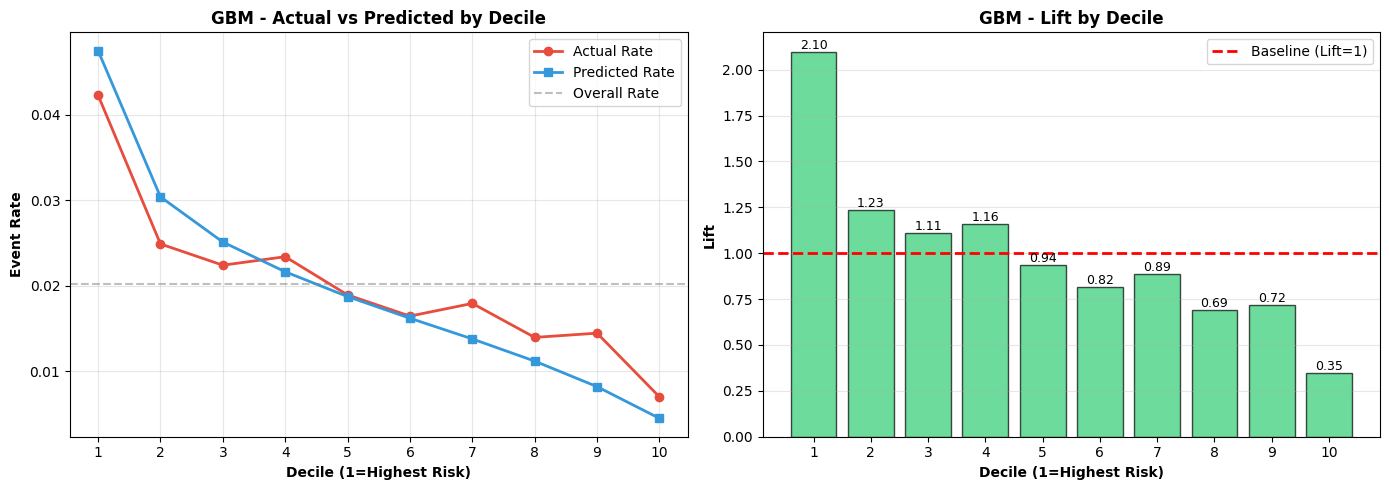


2. RF Model Lift Chart:


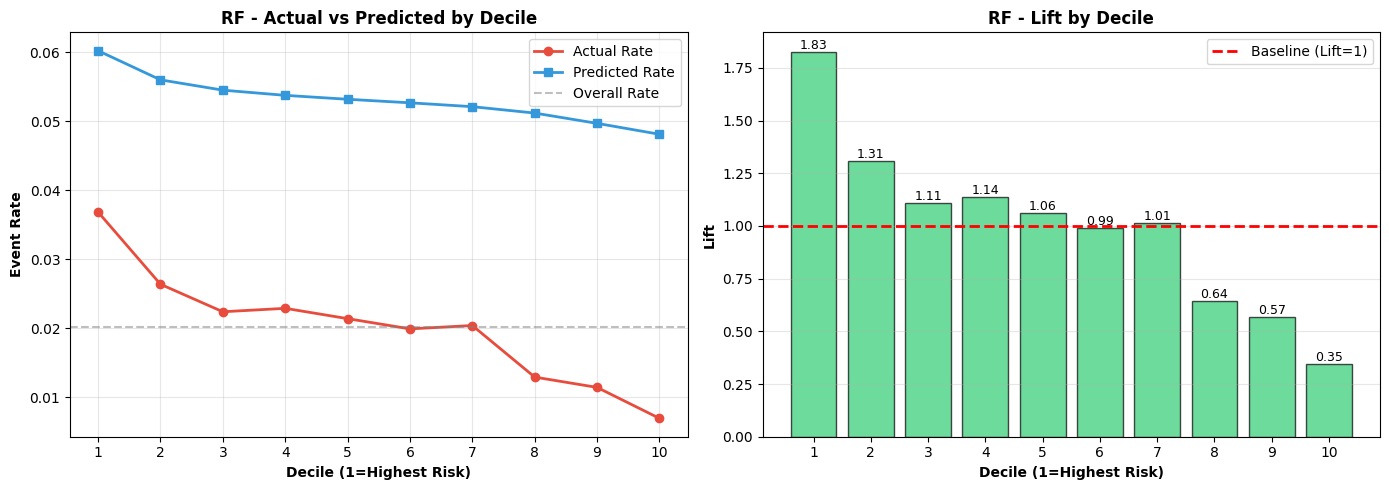


3. GBRF Model Lift Chart:


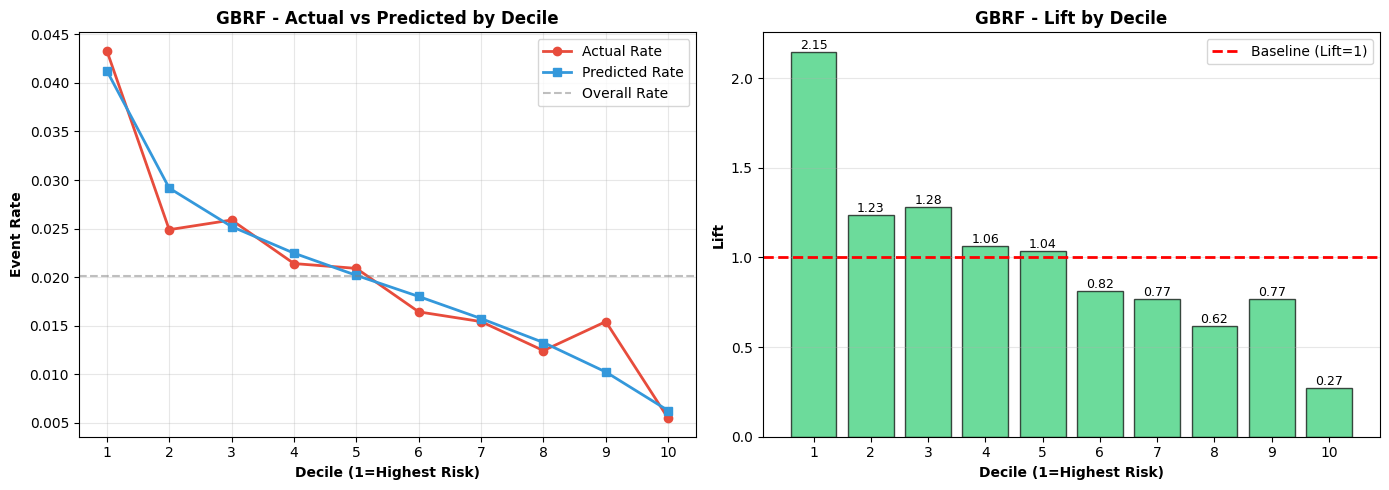


[OK] All lift charts generated successfully!


In [16]:
def create_lift_chart_binary(y_true, y_pred_proba, model_name, bins=10):
    """
    Create lift chart for binary classification.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred_proba : array-like
        Predicted probabilities
    model_name : str
        Name of the model
    bins : int
        Number of deciles (default 10)
    """
    # Create dataframe
    df_lift = pd.DataFrame({
        'true': y_true,
        'pred': y_pred_proba
    })
    
    # Sort by prediction (descending)
    df_lift = df_lift.sort_values('pred', ascending=False).reset_index(drop=True)
    
    # Assign deciles
    df_lift['decile'] = pd.qcut(df_lift.index, bins, labels=False, duplicates='drop') + 1
    
    # Calculate metrics by decile
    decile_stats = df_lift.groupby('decile').agg({
        'true': ['sum', 'count', 'mean'],
        'pred': 'mean'
    }).reset_index()
    
    decile_stats.columns = ['decile', 'actual_events', 'count', 'actual_rate', 'pred_rate']
    
    # Calculate overall rate
    overall_rate = y_true.mean()
    
    # Calculate lift
    decile_stats['lift'] = decile_stats['actual_rate'] / overall_rate
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Actual vs Predicted Rates
    ax1.plot(decile_stats['decile'], decile_stats['actual_rate'], 
             marker='o', linewidth=2, label='Actual Rate', color='#e74c3c')
    ax1.plot(decile_stats['decile'], decile_stats['pred_rate'], 
             marker='s', linewidth=2, label='Predicted Rate', color='#3498db')
    ax1.axhline(y=overall_rate, color='gray', linestyle='--', alpha=0.5, label='Overall Rate')
    ax1.set_xlabel('Decile (1=Highest Risk)', fontweight='bold')
    ax1.set_ylabel('Event Rate', fontweight='bold')
    ax1.set_title(f'{model_name} - Actual vs Predicted by Decile', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(decile_stats['decile'])
    
    # Plot 2: Lift
    bars = ax2.bar(decile_stats['decile'], decile_stats['lift'], 
                   color='#2ecc71', alpha=0.7, edgecolor='black')
    ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (Lift=1)')
    ax2.set_xlabel('Decile (1=Highest Risk)', fontweight='bold')
    ax2.set_ylabel('Lift', fontweight='bold')
    ax2.set_title(f'{model_name} - Lift by Decile', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticks(decile_stats['decile'])
    
    # Add value labels on bars
    for bar, lift_val in zip(bars, decile_stats['lift']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{lift_val:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return decile_stats

# Generate lift charts for all 3 models
if is_binary:
    print("="*80)
    print("LIFT CHART ANALYSIS (10 Deciles)")
    print("="*80)
    
    print("\n1. GBM Model Lift Chart:")
    gbm_lift = create_lift_chart_binary(y_test, boost_test_proba[:, 1], 'GBM', bins=10)
    
    print("\n2. RF Model Lift Chart:")
    rf_lift = create_lift_chart_binary(y_test, rf_test_proba[:, 1], 'RF', bins=10)
    
    print("\n3. GBRF Model Lift Chart:")
    gbrf_lift = create_lift_chart_binary(y_test, gbrf_test_proba[:, 1], 'GBRF', bins=10)
    
    print("\n[OK] All lift charts generated successfully!")
else:
    print("[INFO] Lift charts are designed for binary classification only")

## 11b. CLASS SEPARATION DIAGNOSTIC PLOTS

**Critical Diagnostic**: Check if predictions properly separate class 0 vs class 1.

**Expected behavior:**
- Class 1 (events) should have HIGH prediction values (closer to 1.0)
- Class 0 (non-events) should have LOW prediction values (closer to 0.0)
- If reversed, the model is predicting backwards!

In [17]:
if is_binary:
    print("="*80)
    print("CLASS SEPARATION DIAGNOSTIC ANALYSIS")
    print("="*80)
    print("\nChecking if predictions properly separate classes...\n")
    
    # Calculate statistics for each model
    models_to_check = [
        ('GBM', boost_test_proba[:, 1]),
        ('RF', rf_test_proba[:, 1]),
        ('GBRF', gbrf_test_proba[:, 1])
    ]
    
    diagnostic_results = []
    
    for model_name, predictions in models_to_check:
        # Separate predictions by actual class
        class_0_preds = predictions[y_test == 0]
        class_1_preds = predictions[y_test == 1]
        
        # Calculate means
        mean_class_0 = class_0_preds.mean()
        mean_class_1 = class_1_preds.mean()
        
        # Check if separation is correct
        is_correct = mean_class_1 > mean_class_0
        separation = mean_class_1 - mean_class_0
        
        diagnostic_results.append({
            'Model': model_name,
            'Mean_Class_0': mean_class_0,
            'Mean_Class_1': mean_class_1,
            'Separation': separation,
            'Direction': 'CORRECT' if is_correct else 'REVERSED'
        })
        
        print(f"{model_name} Model:")
        print(f"  - Average prediction for Class 0: {mean_class_0:.4f}")
        print(f"  - Average prediction for Class 1: {mean_class_1:.4f}")
        print(f"  - Separation (Class1 - Class0): {separation:.4f}")
        print(f"  - Status: {diagnostic_results[-1]['Direction']}")
        print()
    
    # Display summary table
    diag_df = pd.DataFrame(diagnostic_results)
    print("\nSUMMARY TABLE:")
    print("="*80)
    print(diag_df.to_string(index=False))
    print("="*80)
else:
    print("[INFO] Class separation diagnostics are for binary classification only")

CLASS SEPARATION DIAGNOSTIC ANALYSIS

Checking if predictions properly separate classes...

GBM Model:
  - Average prediction for Class 0: 0.0196
  - Average prediction for Class 1: 0.0254
  - Separation (Class1 - Class0): 0.0059
  - Status: CORRECT

RF Model:
  - Average prediction for Class 0: 0.0531
  - Average prediction for Class 1: 0.0546
  - Separation (Class1 - Class0): 0.0015
  - Status: CORRECT

GBRF Model:
  - Average prediction for Class 0: 0.0201
  - Average prediction for Class 1: 0.0252
  - Separation (Class1 - Class0): 0.0051
  - Status: CORRECT


SUMMARY TABLE:
Model  Mean_Class_0  Mean_Class_1  Separation Direction
  GBM      0.019595      0.025446    0.005851   CORRECT
   RF      0.053094      0.054564    0.001470   CORRECT
 GBRF      0.020082      0.025174    0.005092   CORRECT


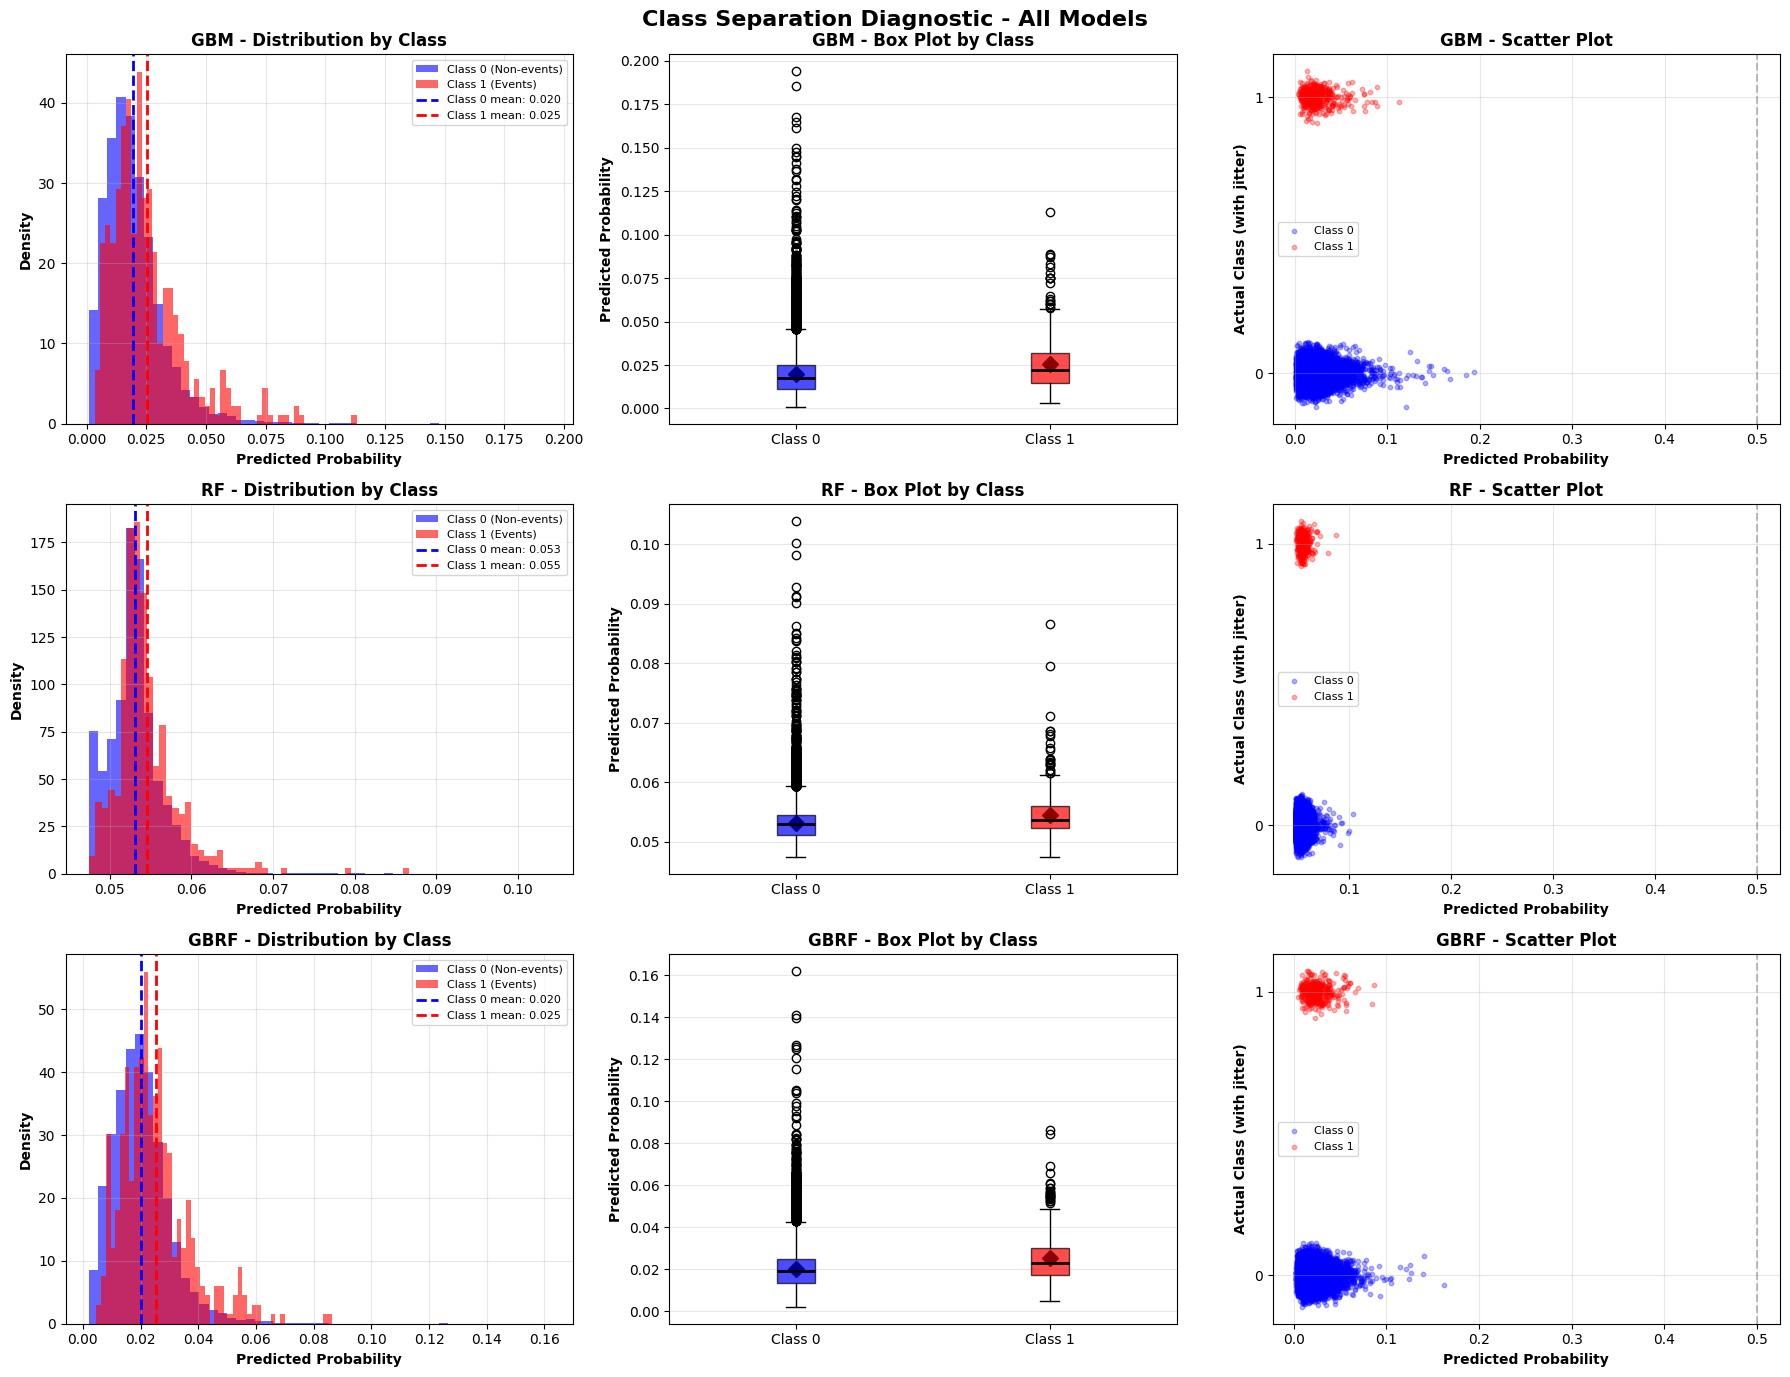


[OK] Class separation diagnostic plots generated!

INTERPRETATION:
  **GOOD MODEL:** Red distribution (Class 1) is to the RIGHT of Blue (Class 0)
  **BAD MODEL:** Red distribution (Class 1) is to the LEFT of Blue (Class 0)
  **MIXED:** Distributions heavily overlap - poor discrimination


In [18]:
if is_binary:
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle('Class Separation Diagnostic - All Models', fontsize=16, fontweight='bold')
    
    models_data = [
        ('GBM', boost_test_proba[:, 1], '#e74c3c'),
        ('RF', rf_test_proba[:, 1], '#3498db'),
        ('GBRF', gbrf_test_proba[:, 1], '#2ecc71')
    ]
    
    for idx, (model_name, predictions, color) in enumerate(models_data):
        # Separate by actual class
        class_0_preds = predictions[y_test == 0]
        class_1_preds = predictions[y_test == 1]
        
        # Plot 1: Distribution (Histogram)
        ax1 = axes[idx, 0]
        ax1.hist(class_0_preds, bins=50, alpha=0.6, color='blue', label='Class 0 (Non-events)', density=True)
        ax1.hist(class_1_preds, bins=50, alpha=0.6, color='red', label='Class 1 (Events)', density=True)
        ax1.axvline(class_0_preds.mean(), color='blue', linestyle='--', linewidth=2, label=f'Class 0 mean: {class_0_preds.mean():.3f}')
        ax1.axvline(class_1_preds.mean(), color='red', linestyle='--', linewidth=2, label=f'Class 1 mean: {class_1_preds.mean():.3f}')
        ax1.set_xlabel('Predicted Probability', fontweight='bold')
        ax1.set_ylabel('Density', fontweight='bold')
        ax1.set_title(f'{model_name} - Distribution by Class', fontweight='bold')
        ax1.legend(fontsize=8, loc='upper right')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Box Plot
        ax2 = axes[idx, 1]
        box_data = [class_0_preds, class_1_preds]
        bp = ax2.boxplot(box_data, labels=['Class 0', 'Class 1'], patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        boxprops=dict(facecolor='lightblue', alpha=0.7))
        bp['boxes'][0].set_facecolor('blue')
        bp['boxes'][1].set_facecolor('red')
        ax2.set_ylabel('Predicted Probability', fontweight='bold')
        ax2.set_title(f'{model_name} - Box Plot by Class', fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add mean markers
        ax2.plot([1], [class_0_preds.mean()], marker='D', markersize=8, color='darkblue', label='Mean')
        ax2.plot([2], [class_1_preds.mean()], marker='D', markersize=8, color='darkred')
        
        # Plot 3: Scatter with Jitter
        ax3 = axes[idx, 2]
        # Add jitter to y-axis for visibility
        jitter_0 = np.random.normal(0, 0.03, size=len(class_0_preds))
        jitter_1 = np.random.normal(1, 0.03, size=len(class_1_preds))
        
        ax3.scatter(class_0_preds, jitter_0, alpha=0.3, s=10, color='blue', label='Class 0')
        ax3.scatter(class_1_preds, jitter_1, alpha=0.3, s=10, color='red', label='Class 1')
        ax3.set_xlabel('Predicted Probability', fontweight='bold')
        ax3.set_ylabel('Actual Class (with jitter)', fontweight='bold')
        ax3.set_title(f'{model_name} - Scatter Plot', fontweight='bold')
        ax3.set_yticks([0, 1])
        ax3.set_yticklabels(['0', '1'])
        ax3.legend(fontsize=8)
        ax3.grid(True, alpha=0.3)
        ax3.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold=0.5')
    
    plt.tight_layout()
    plt.show()
    
    print("\n[OK] Class separation diagnostic plots generated!")
    print("\nINTERPRETATION:")
    print("  **GOOD MODEL:** Red distribution (Class 1) is to the RIGHT of Blue (Class 0)")
    print("  **BAD MODEL:** Red distribution (Class 1) is to the LEFT of Blue (Class 0)")
    print("  **MIXED:** Distributions heavily overlap - poor discrimination")
else:
    print("[INFO] Class separation plots are for binary classification only")

In [19]:
# Additional diagnostic: Check sample predictions
if is_binary:
    print("\n" + "="*80)
    print("SAMPLE PREDICTIONS CHECK")
    print("="*80)
    
    # Show examples of high and low predictions
    sample_df = pd.DataFrame({
        'Actual_Class': y_test.values[:20],
        'GBM_Pred': boost_test_proba[:20, 1],
        'RF_Pred': rf_test_proba[:20, 1],
        'GBRF_Pred': gbrf_test_proba[:20, 1]
    })
    
    print("\nFirst 20 predictions (check if Class=1 has higher predictions):")
    print(sample_df.to_string(index=True))
    
    # Find examples with actual class = 1
    class_1_examples = sample_df[sample_df['Actual_Class'] == 1]
    class_0_examples = sample_df[sample_df['Actual_Class'] == 0]
    
    if len(class_1_examples) > 0:
        print("\n Examples where Actual Class = 1:")
        print(class_1_examples.to_string())
        print(f"   -> Average GBM prediction: {class_1_examples['GBM_Pred'].mean():.4f}")
    
    if len(class_0_examples) > 0:
        print("\n Examples where Actual Class = 0:")
        print(class_0_examples.head(5).to_string())
        print(f"   -> Average GBM prediction: {class_0_examples['GBM_Pred'].mean():.4f}")
    
    print("\n" + "="*80)


SAMPLE PREDICTIONS CHECK

First 20 predictions (check if Class=1 has higher predictions):
    Actual_Class  GBM_Pred   RF_Pred  GBRF_Pred
0              0  0.033606  0.055099   0.025401
1              0  0.024763  0.052302   0.025922
2              0  0.037403  0.059428   0.043318
3              0  0.009317  0.051139   0.013973
4              0  0.015940  0.053543   0.019932
5              0  0.018602  0.052492   0.018712
6              0  0.019932  0.054983   0.022911
7              0  0.019388  0.061331   0.023673
8              0  0.014411  0.049757   0.012710
9              0  0.006366  0.049013   0.009957
10             0  0.044402  0.059050   0.039711
11             0  0.012486  0.054966   0.017790
12             0  0.012263  0.053898   0.019552
13             0  0.011548  0.051415   0.014572
14             0  0.017672  0.052177   0.017078
15             0  0.049593  0.063314   0.046003
16             0  0.011193  0.052047   0.013007
17             0  0.005016  0.048206   0.0068

## 12. ROC and Precision-Recall Curves

Compare all three models using ROC and PR curves.

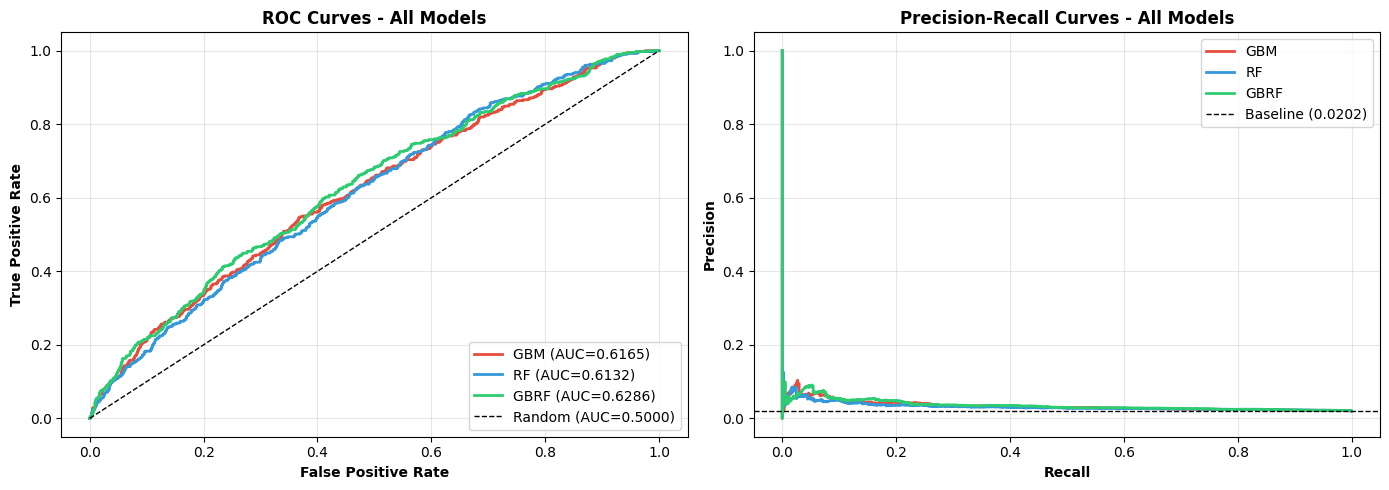

[OK] ROC and PR curves generated successfully!


In [20]:
if is_binary:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC Curves
    gbm_fpr, gbm_tpr, _ = roc_curve(y_test, boost_test_proba[:, 1])
    rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_proba[:, 1])
    gbrf_fpr, gbrf_tpr, _ = roc_curve(y_test, gbrf_test_proba[:, 1])
    
    ax1.plot(gbm_fpr, gbm_tpr, linewidth=2, label=f'GBM (AUC={boost_test_auc:.4f})', color='#e74c3c')
    ax1.plot(rf_fpr, rf_tpr, linewidth=2, label=f'RF (AUC={rf_test_auc:.4f})', color='#3498db')
    ax1.plot(gbrf_fpr, gbrf_tpr, linewidth=2, label=f'GBRF (AUC={gbrf_test_auc:.4f})', color='#2ecc71')
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5000)')
    ax1.set_xlabel('False Positive Rate', fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontweight='bold')
    ax1.set_title('ROC Curves - All Models', fontweight='bold', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    # Precision-Recall Curves
    gbm_precision, gbm_recall, _ = precision_recall_curve(y_test, boost_test_proba[:, 1])
    rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_test_proba[:, 1])
    gbrf_precision, gbrf_recall, _ = precision_recall_curve(y_test, gbrf_test_proba[:, 1])
    
    baseline = y_test.mean()
    
    ax2.plot(gbm_recall, gbm_precision, linewidth=2, label='GBM', color='#e74c3c')
    ax2.plot(rf_recall, rf_precision, linewidth=2, label='RF', color='#3498db')
    ax2.plot(gbrf_recall, gbrf_precision, linewidth=2, label='GBRF', color='#2ecc71')
    ax2.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.4f})')
    ax2.set_xlabel('Recall', fontweight='bold')
    ax2.set_ylabel('Precision', fontweight='bold')
    ax2.set_title('Precision-Recall Curves - All Models', fontweight='bold', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("[OK] ROC and PR curves generated successfully!")
else:
    print("[INFO] ROC/PR curves shown are for binary classification")

## 13. Confusion Matrices

Visualize prediction performance with confusion matrices.

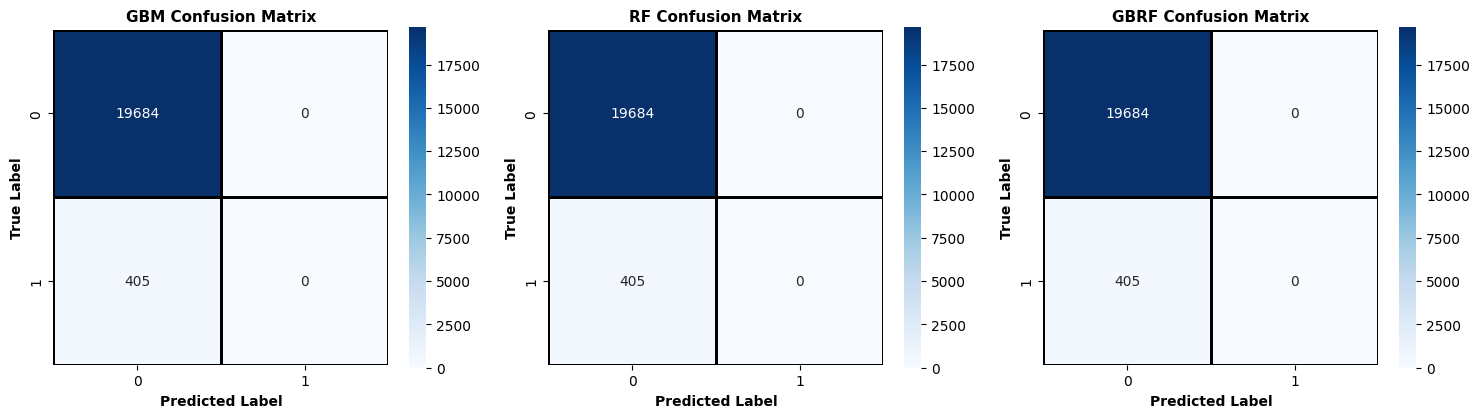

[OK] Confusion matrices generated successfully!


In [21]:
# Create confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_data = [
    ('GBM', boost_test_pred, '#e74c3c'),
    ('RF', rf_test_pred, '#3498db'),
    ('GBRF', gbrf_test_pred, '#2ecc71')
]

for idx, (model_name, predictions, color) in enumerate(models_data):
    cm = confusion_matrix(y_test, predictions)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=True, square=True, linewidths=1, linecolor='black')
    axes[idx].set_title(f'{model_name} Confusion Matrix', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('True Label', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

print("[OK] Confusion matrices generated successfully!")

## 14. Calibration Plots

Check how well predicted probabilities match actual outcomes.

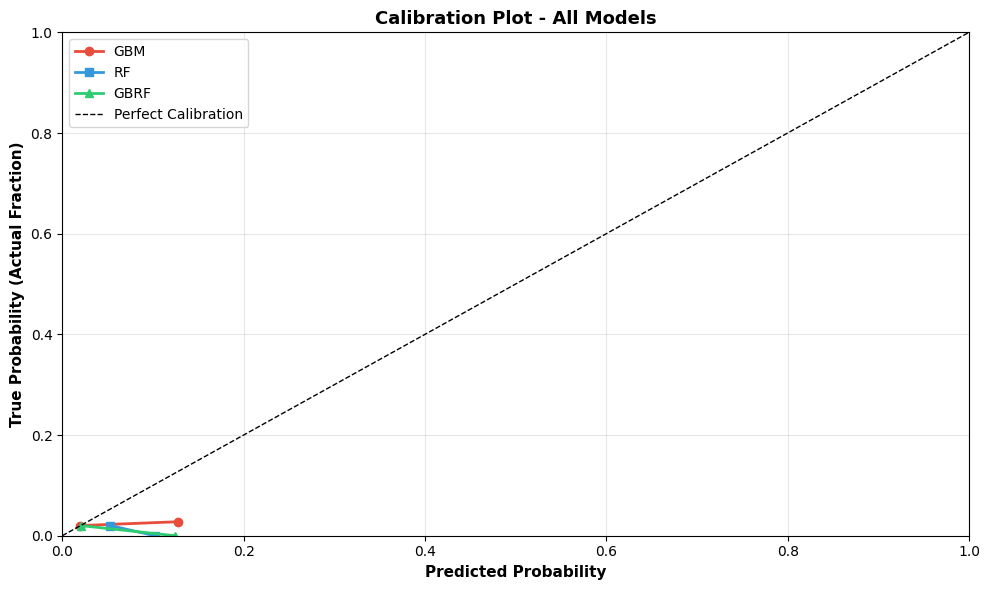

[OK] Calibration plot generated successfully!

Interpretation:
  - Points on diagonal line = perfect calibration
  - Points above line = model underestimates probability
  - Points below line = model overestimates probability


In [22]:
if is_binary:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Calculate calibration curves for all models
    gbm_prob_true, gbm_prob_pred = calibration_curve(y_test, boost_test_proba[:, 1], n_bins=10)
    rf_prob_true, rf_prob_pred = calibration_curve(y_test, rf_test_proba[:, 1], n_bins=10)
    gbrf_prob_true, gbrf_prob_pred = calibration_curve(y_test, gbrf_test_proba[:, 1], n_bins=10)
    
    # Plot calibration curves
    ax.plot(gbm_prob_pred, gbm_prob_true, marker='o', linewidth=2, label='GBM', color='#e74c3c')
    ax.plot(rf_prob_pred, rf_prob_true, marker='s', linewidth=2, label='RF', color='#3498db')
    ax.plot(gbrf_prob_pred, gbrf_prob_true, marker='^', linewidth=2, label='GBRF', color='#2ecc71')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Calibration')
    
    ax.set_xlabel('Predicted Probability', fontweight='bold', fontsize=11)
    ax.set_ylabel('True Probability (Actual Fraction)', fontweight='bold', fontsize=11)
    ax.set_title('Calibration Plot - All Models', fontweight='bold', fontsize=13)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    print("[OK] Calibration plot generated successfully!")
    print("\nInterpretation:")
    print("  - Points on diagonal line = perfect calibration")
    print("  - Points above line = model underestimates probability")
    print("  - Points below line = model overestimates probability")
else:
    print("[INFO] Calibration plots shown are for binary classification")

## 15. Feature Importance Comparison

Compare which features are most important across all three models.


Top 15 Features by Average Importance:
                          Feature      GBM       RF     GBRF  Average
                        LOO_years 0.026326 0.041080 0.028927 0.032111
                           credit 0.022289 0.045802 0.025183 0.031091
                      veh_age_box 0.024675 0.033367 0.027639 0.028560
                  rental_use_flag 0.019130 0.039498 0.019518 0.026049
             Severe_Accident_flag 0.021958 0.030258 0.019967 0.024061
Annual_Mileage_Estimate_null_flag 0.018535 0.030446 0.022247 0.023743
                    diploma_ntile 0.020697 0.023299 0.022117 0.022037
                pop_density_ntile 0.019750 0.024853 0.020813 0.021806
        Estimated_Current_Mileage 0.019802 0.024541 0.020842 0.021728
                  coll_symb_ntile 0.020904 0.021296 0.022636 0.021612
                         CPO_flag 0.022457 0.019411 0.022650 0.021506
                     commute_flag 0.021945 0.019557 0.022837 0.021446
          Nonsevere_Accident_flag 0.019073 0.02594

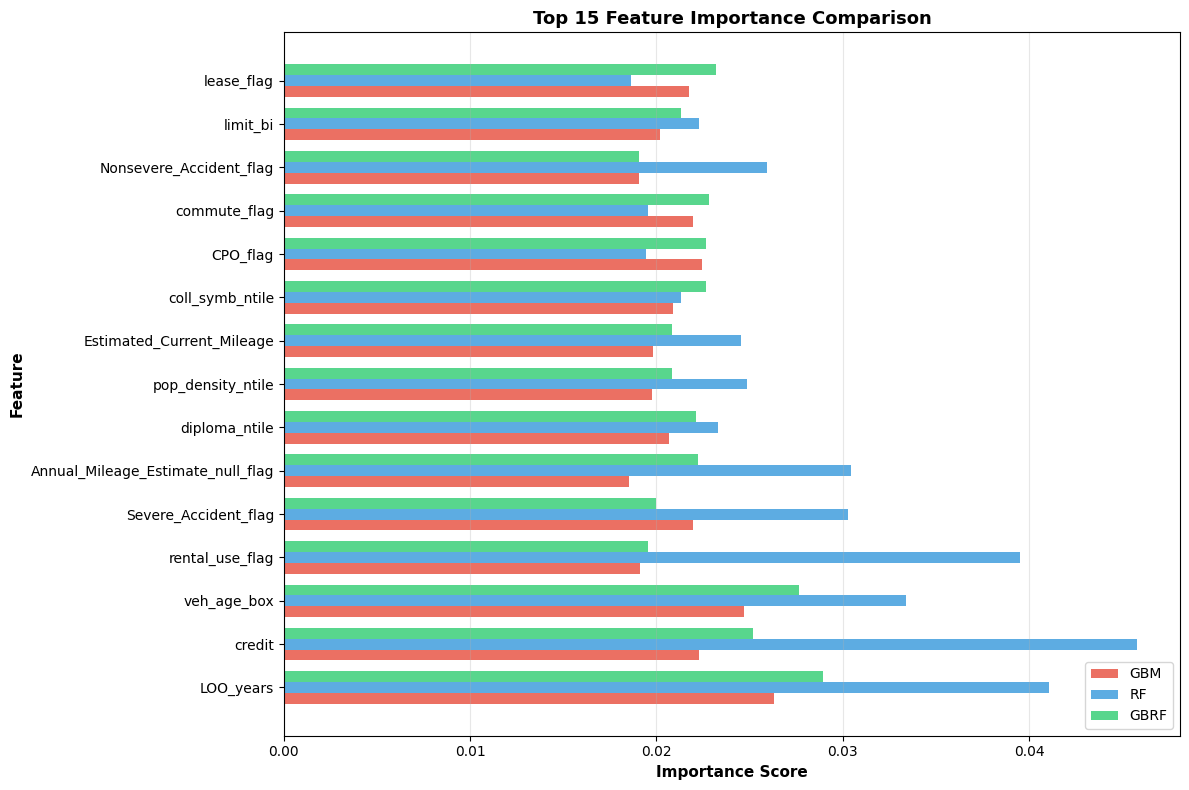


[OK] Feature importance analysis complete!


In [23]:
# Get feature importance from all models
feature_names = X.columns

gbm_importance = boost_model.feature_importances_
rf_importance = rf_model.feature_importances_
gbrf_importance = gbrf_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'GBM': gbm_importance,
    'RF': rf_importance,
    'GBRF': gbrf_importance
})

# Calculate average importance and sort
importance_df['Average'] = importance_df[['GBM', 'RF', 'GBRF']].mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False).reset_index(drop=True)

# Display top 15 features
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)

print(f"\nTop {top_n} Features by Average Importance:")
print("="*80)
print(top_features.to_string(index=False))
print("="*80)

# Visualize top features
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(top_n)
width = 0.25

ax.barh(x - width, top_features['GBM'], width, label='GBM', color='#e74c3c', alpha=0.8)
ax.barh(x, top_features['RF'], width, label='RF', color='#3498db', alpha=0.8)
ax.barh(x + width, top_features['GBRF'], width, label='GBRF', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Feature', fontweight='bold', fontsize=11)
ax.set_xlabel('Importance Score', fontweight='bold', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importance Comparison', fontweight='bold', fontsize=13)
ax.set_yticks(x)
ax.set_yticklabels(top_features['Feature'])
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n[OK] Feature importance analysis complete!")

## 16. Alternative: Compare with sklearn's RandomForest

For a more traditional comparison, you might also want to compare XGBoost's boosting with scikit-learn's RandomForestClassifier:

In [24]:
from sklearn.ensemble import RandomForestClassifier

print("Training sklearn's RandomForestClassifier for comparison...")

sklearn_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    max_features=0.8,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
sklearn_rf.fit(X_train, y_train)
sklearn_rf_train_time = time.time() - start_time

# Predictions
sklearn_rf_test_pred = sklearn_rf.predict(X_test)
sklearn_rf_test_proba = sklearn_rf.predict_proba(X_test)

# Metrics
if is_binary:
    sklearn_rf_test_auc = roc_auc_score(y_test, sklearn_rf_test_proba[:, 1])
else:
    sklearn_rf_test_auc = roc_auc_score(y_test, sklearn_rf_test_proba, multi_class='ovr')

sklearn_rf_test_acc = accuracy_score(y_test, sklearn_rf_test_pred)

print(f"\n✓ sklearn RF Training Time: {sklearn_rf_train_time:.4f}s")
print(f"✓ sklearn RF Test {metric_name}: {sklearn_rf_test_auc:.4f}")
print(f"✓ sklearn RF Test Accuracy: {sklearn_rf_test_acc:.4f}")

print("\n" + "="*80)
print("THREE-WAY COMPARISON")
print("="*80)
print(f"{'Model':<25} {'Test ' + metric_name:<15} {'Test Accuracy':<15} {'Train Time (s)'}")
print("-"*80)
print(f"{'XGBoost Boosting':<25} {boost_test_auc:<15.4f} {boost_test_acc:<15.4f} {boost_train_time:.4f}")
print(f"{'XGBoost RF Mode':<25} {rf_test_auc:<15.4f} {rf_test_acc:<15.4f} {rf_train_time:.4f}")
print(f"{'sklearn RandomForest':<25} {sklearn_rf_test_auc:<15.4f} {sklearn_rf_test_acc:<15.4f} {sklearn_rf_train_time:.4f}")
print("="*80)

Training sklearn's RandomForestClassifier for comparison...

✓ sklearn RF Training Time: 3.0055s
✓ sklearn RF Test AUC: 0.6089
✓ sklearn RF Test Accuracy: 0.9798

THREE-WAY COMPARISON
Model                     Test AUC        Test Accuracy   Train Time (s)
--------------------------------------------------------------------------------
XGBoost Boosting          0.6165          0.9798          0.6887
XGBoost RF Mode           0.6132          0.9798          0.6870
sklearn RandomForest      0.6089          0.9798          3.0055


## 12. Summary and Conclusions

In [25]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print("\n EXPERIMENTAL SETUP:")
print(f"  - Dataset size: {len(df)} samples")
print(f"  - Features: {X.shape[1]}")
print(f"  - Train/Test split: 80/20")
print(f"  - Problem type: {n_classes}-class classification")

print("\n MODEL CONFIGURATIONS:")
print("  Both models used:")
print("    - 200 total trees")
print("    - max_depth = 6")
print("    - subsample = 0.8")
print("    - colsample = 0.8")
print("    - random_state = 42")

print("\n PERFORMANCE COMPARISON:")
winner = "GBM" if boost_test_auc > rf_test_auc else "Random Forest"
print(f"  Winner: {winner} (higher test {metric_name})")
print(f"  Better generalization: {'Random Forest' if rf_gap < boost_gap else 'GBM'} (smaller gap)")
print(f"  Faster training: {'Random Forest' if rf_train_time < boost_train_time else 'GBM'}")

print("\n RECOMMENDATION:")
if boost_test_auc > rf_test_auc and boost_gap < 0.05:
    print("  -> Use Gradient Boosting: Better performance without excessive overfitting")
elif rf_gap < boost_gap and abs(boost_test_auc - rf_test_auc) < 0.02:
    print("  -> Use Random Forest: Similar performance with better generalization")
elif boost_test_auc > rf_test_auc:
    print("  -> Use Gradient Boosting: Superior test performance")
else:
    print("  -> Use Random Forest: Better overall balance")

print("\n" + "="*80)
print("GOOD: Analysis Complete!")
print("="*80)


FINAL SUMMARY

 EXPERIMENTAL SETUP:
  - Dataset size: 100443 samples
  - Features: 54
  - Train/Test split: 80/20
  - Problem type: 2-class classification

 MODEL CONFIGURATIONS:
  Both models used:
    - 200 total trees
    - max_depth = 6
    - subsample = 0.8
    - colsample = 0.8
    - random_state = 42

 PERFORMANCE COMPARISON:
  Winner: GBM (higher test AUC)
  Better generalization: Random Forest (smaller gap)
  Faster training: Random Forest

 RECOMMENDATION:
  -> Use Random Forest: Similar performance with better generalization

GOOD: Analysis Complete!
